# Error Analysis — BERT BBC News Classifier
Analyse misclassifications from the baseline model.
Model: bert-bbc-finetuned (fine-tuned on 800 samples, 3 epochs)
Test set: 100 samples

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import BertForSequenceClassification, BertTokenizer

sns.set_theme(style="whitegrid")
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT = Path(os.getcwd()).parent
print(f"Device: {device}")

Device: cuda


In [5]:
PROJECT_ROOT = Path(os.getcwd()).parent
results_df   = pd.read_csv(PROJECT_ROOT / "reports" / "bert_baseline_test_predictions.csv")

In [11]:
SAVE_PATH = PROJECT_ROOT / "models" / "bert-bbc-finetuned"

model     = BertForSequenceClassification.from_pretrained(SAVE_PATH)
tokenizer = BertTokenizer.from_pretrained(SAVE_PATH)

model     = model.to(device)
model.eval()

ID2LABEL = model.config.id2label
LABEL2ID = model.config.label2id

print(f"Model loaded ✅")
print(f"Labels: {ID2LABEL}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded ✅
Labels: {0: 'business', 1: 'entertainment', 2: 'politics', 3: 'sport', 4: 'tech'}


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
model = model.to(device)
model.eval()

print("Model loaded ✅")

Model loaded ✅


In [13]:
# load the exact same test set used in notebook 2
test_df = pd.read_csv(PROJECT_ROOT / "reports" / "test_set.csv")
print(f"Test samples: {len(test_df)}")
test_df.head()

Test samples: 100


,body,title,category,label
0,Comic book veteran Stan Lee is to team up with...,Lee to create new film superhero,entertainment,1
1,Everton manager David Moyes will discipline st...,Moyes U-turn on Beattie dismissal,sport,3
2,European leaders say Asian states must let the...,Europe asks Asia for euro help,business,0
3,"UK house prices increased by 1.1% in December,...",House prices rebound says Halifax,business,0
4,Internet TV has been talked about since the st...,TV's future down the phone line,tech,4


In [14]:
# notebook 3 — no model needed at all
results_df = pd.read_csv(PROJECT_ROOT / "reports" / "test_predictions.csv")

In [15]:
print(f"Total samples : {len(results_df)}")
print(f"Correct       : {results_df['correct'].sum()}")
print(f"Errors        : {(~results_df['correct']).sum()}")
print(f"Accuracy      : {results_df['correct'].mean():.4f}")
print()
print("Class distribution in test set:")
print(results_df['true_label'].value_counts())

Total samples : 100
Correct       : 100
Errors        : 0
Accuracy      : 1.0000

Class distribution in test set:
true_label
sport            23
business         22
politics         20
tech             18
entertainment    17
Name: count, dtype: int64


In [16]:
errors_df  = results_df[~results_df["correct"]].reset_index(drop=True)
correct_df = results_df[results_df["correct"]].reset_index(drop=True)

print(f"Misclassified samples: {len(errors_df)}")
print()
for _, row in errors_df.iterrows():
    print(f"Title          : {row['title']}")
    print(f"True label     : {row['true_label']}")
    print(f"Predicted      : {row['predicted']}")
    print(f"Confidence     : {row['confidence']:.4f}  (on wrong prediction)")
    print(f"True confidence: {row['true_confidence']:.4f}  (on correct class)")
    print(f"Body preview   : {row['body'][:300]}")
    print("-" * 60)

Misclassified samples: 0



In [17]:
print(results_df["correct"].value_counts())
print(results_df[["true_label", "predicted", "correct"]].head(10))

correct
True    100
Name: count, dtype: int64
      true_label      predicted  correct
0  entertainment  entertainment     True
1          sport          sport     True
2       business       business     True
3       business       business     True
4           tech           tech     True
5       politics       politics     True
6           tech           tech     True
7       politics       politics     True
8          sport          sport     True
9       politics       politics     True


C:\Users\mrinm\AppData\Local\Temp\ipykernel_26420\786800280.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


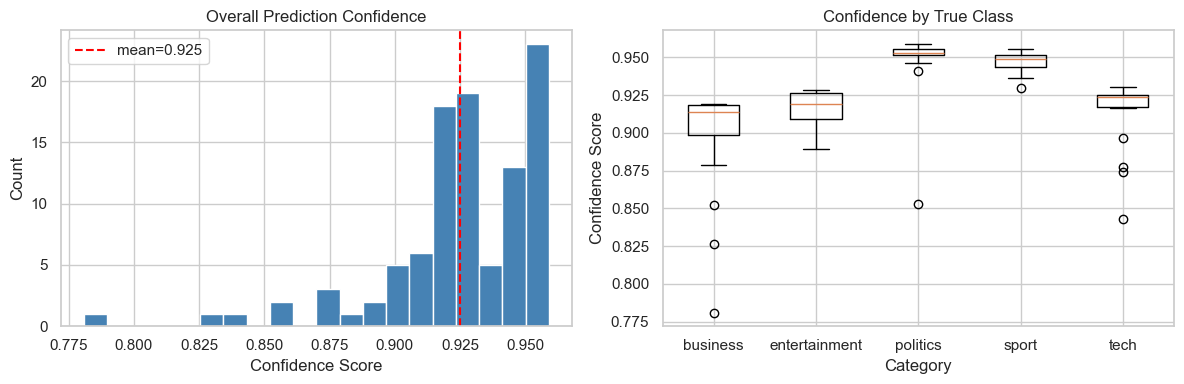

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# overall confidence
axes[0].hist(results_df["confidence"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Overall Prediction Confidence")
axes[0].set_xlabel("Confidence Score")
axes[0].set_ylabel("Count")
axes[0].axvline(
    results_df["confidence"].mean(), 
    color="red", linestyle="--", 
    label=f"mean={results_df['confidence'].mean():.3f}"
)
axes[0].legend()

# confidence per class
axes[1].boxplot(
    [results_df[results_df["true_label"]==label]["confidence"].values 
     for label in ["business","entertainment","politics","sport","tech"]],
    labels=["business","entertainment","politics","sport","tech"]
)
axes[1].set_title("Confidence by True Class")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Confidence Score")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "confidence_distribution.png", dpi=150)
plt.show()

In [20]:
# even correct predictions — where was the model least sure?
low_confidence = results_df.nsmallest(5, "confidence")

print("5 lowest confidence predictions (all correct):")
print()
for _, row in low_confidence.iterrows():
    print(f"Title          : {row['title']}")
    print(f"True label     : {row['true_label']}")
    print(f"Predicted      : {row['predicted']}")
    print(f"Confidence     : {row['confidence']:.4f}")
    print(f"Body preview   : {row['body'][:200]}")
    print("-" * 60)

5 lowest confidence predictions (all correct):

Title          : EU ministers to mull jet fuel tax
True label     : business
Predicted      : business
Confidence     : 0.7809
Body preview   : European Union finance ministers are meeting on Thursday in Brussels, where they are to discuss a controversial jet fuel tax.

A levy on jet fuel has been suggested as a way to raise funds to finance 
------------------------------------------------------------
Title          : Egypt and Israel seal trade deal
True label     : business
Predicted      : business
Confidence     : 0.8262
Body preview   : In a sign of a thaw in relations between Egypt and Israel, the two countries have signed a trade protocol with the US, allowing Egyptian goods made in partnership with Israeli firms free access to Ame
------------------------------------------------------------
Title          : Anti-spam laws bite spammer hard
True label     : tech
Predicted      : tech
Confidence     : 0.8427
Body preview   : The ne